In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('train.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
# ── Preprocessing ──────────────────────────────────────────────────────────
target = 'SalePrice'
X = df.drop(columns=[target, 'Id'])
y = df[target]

# Fill missing values
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna('None')
for col in X.select_dtypes(include='number').columns:
    X[col] = X[col].fillna(X[col].median())

# Encode categoricals
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

print('Features:', X.shape[1])
print('Missing values:', X.isnull().sum().sum())

Features: 79
Missing values: 0


In [14]:
# ── Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')

Train: 1168 rows  |  Test: 292 rows


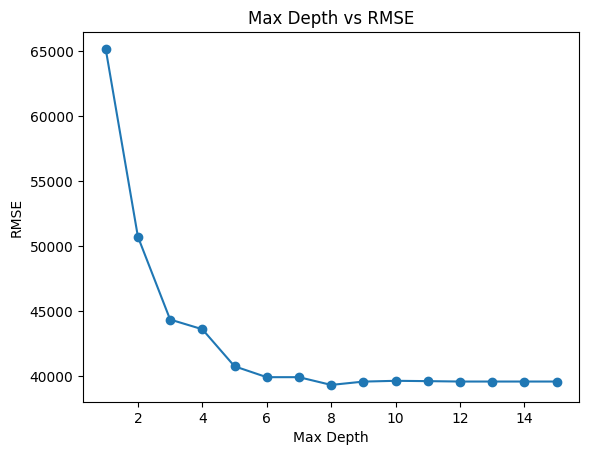

Best max_depth: 8


DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

In [15]:
# ── Tune max_depth ────────────────────────────────────────────────────────
depths = range(1, 16)
rmse_values = []

for d in depths:
    dt = DecisionTreeRegressor(
        max_depth=d,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    )
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_values.append(rmse)

# Plot graph
plt.figure()
plt.plot(depths, rmse_values, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('Max Depth vs RMSE')
plt.show()

# Best depth
best_depth = depths[np.argmin(rmse_values)]
print(f"Best max_depth: {best_depth}")

# Train final model
dt = DecisionTreeRegressor(
    max_depth=best_depth,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

In [16]:
# ── Evaluation ─────────────────────────────────────────────────────────────
y_pred = dt.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Cross-validated RMSE (5-fold)
cv_scores = cross_val_score(dt, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse   = np.sqrt(-cv_scores.mean())

print(f'Test  RMSE : ${rmse:,.0f}')
print(f'Test  R²   : {r2:.4f}')
print(f'CV    RMSE : ${cv_rmse:,.0f}  (5-fold)')

Test  RMSE : $39,329
Test  R²   : 0.7983
CV    RMSE : $38,630  (5-fold)


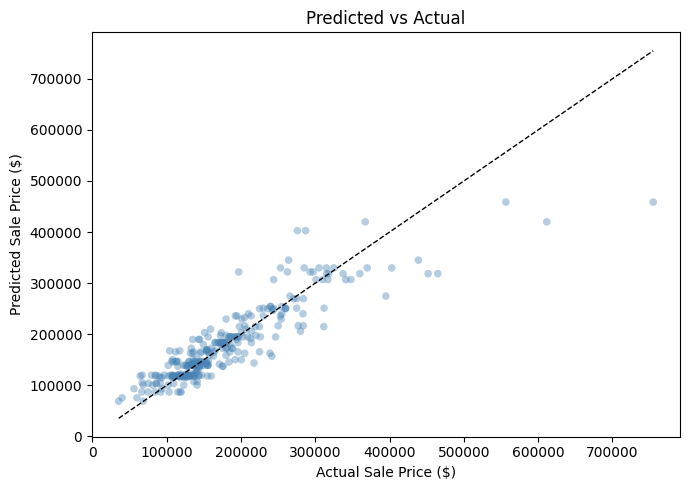

In [17]:
# ── Predicted vs Actual ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, alpha=0.4, edgecolors='none', color='steelblue', s=30)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Sale Price ($)')
ax.set_ylabel('Predicted Sale Price ($)')
ax.set_title('Predicted vs Actual')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

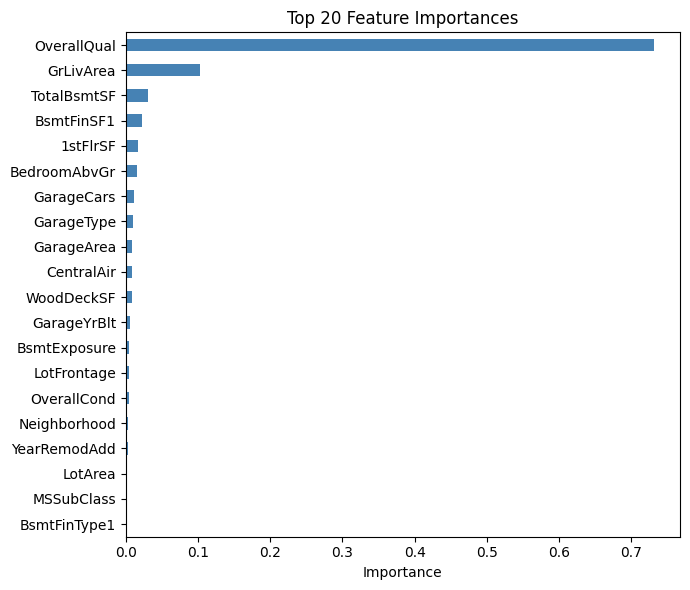

In [18]:
# ── Feature Importance ─────────────────────────────────────────────────────
importances = pd.Series(dt.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

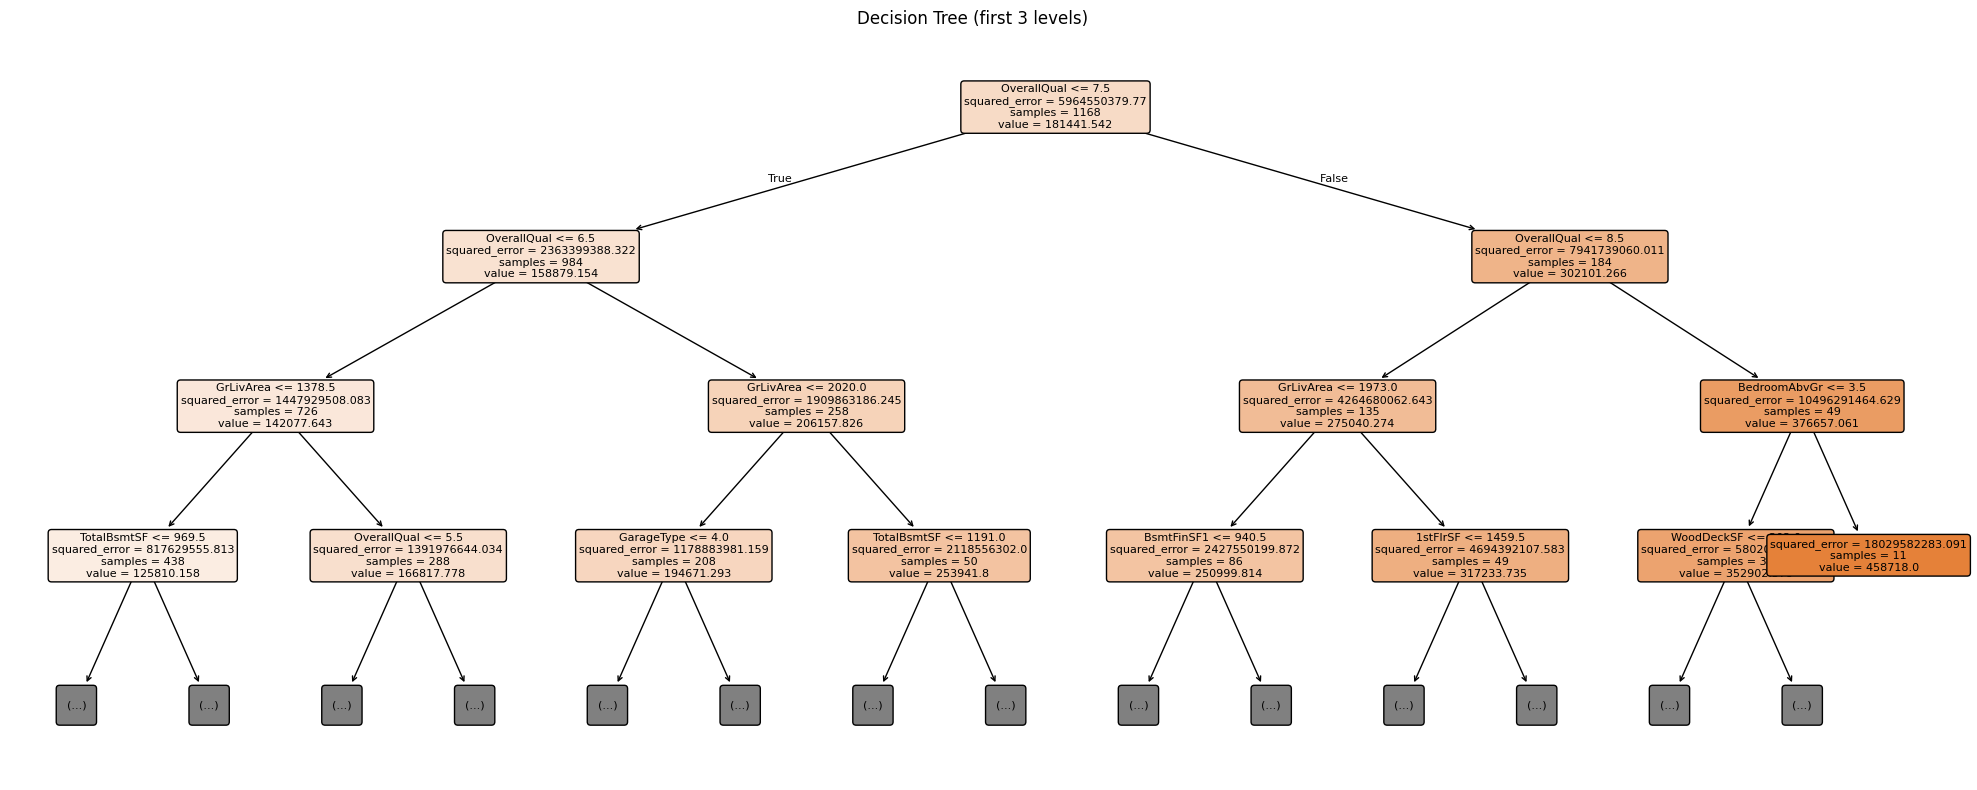

In [19]:
# ── Visualise the Tree (first 3 levels) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=3,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.title('Decision Tree (first 3 levels)')
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=150)
plt.show()

In [20]:
# ── Generate test.csv predictions ───────────────────────────────
import os
if os.path.exists('test.csv'):
    test_df = pd.read_csv('test.csv')
    ids = test_df['Id']
    X_test_final = test_df.drop(columns=['Id'])
    for col in X_test_final.select_dtypes(include='object').columns:
        X_test_final[col] = X_test_final[col].fillna('None')
    for col in X_test_final.select_dtypes(include='number').columns:
        X_test_final[col] = X_test_final[col].fillna(X_test_final[col].median())
    for col in X_test_final.select_dtypes(include='object').columns:
        X_test_final[col] = le.fit_transform(X_test_final[col])
    preds = dt.predict(X_test_final)
    submission = pd.DataFrame({'Id': ids, 'SalePrice': preds})
    submission.to_csv('submission.csv', index=False)
    print('submission.csv saved')
else:
    print('No test.csv found — skipping submission generation')

submission.csv saved
